# Notebook 05 — VGG-style + Data Augmentation

**არქიტექტურა #4: VGG-mini + augmentation**

წინა notebook-ში regularization-მა მაგრად ვერ მოაგვარა overfit-ი — gap ~40% დარჩა. ახლა ვცადოთ ორი რამე ერთად: deeper architecture (VGG-stilis) და data augmentation.

logic მარტივია — model-ი მაგარი ძლიერია, train data კი ცოტა variable-ი. ე.ი. ან model-ი დავაპატარავოთ (capacity-ი მიდის), ან train data-ს variability მივცეთ. augmentation მეორე გზაა.

**VGG-mini setup:**
- 4 conv block, თითო ბლოკში 2 conv (გარდა ბოლოსი — იქ 1)
- filters: 32 → 64 → 128 → 256
- BN ყველგან + Dropout 0.5 FC-ში

**3 runs:**
1. **A** — augmentation-ის გარეშე, რომ ვნახოთ deeper net-ი მარტო რას იძლევა
2. **B** — mild aug (flip + ცოტა rotation + ცოტა translation)
3. **C** — full aug (flip + affine + random crop) + ბევრი epoch — final push

თეორიულად Run A overfit-ი იქნება MediumCNN-ის მსგავსად, Run B უკვე უკეთესი, Run C — best.

In [1]:
# Setup
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
PROJECT_DIR = '/content/drive/MyDrive/ML_davaleba_4'
os.chdir(PROJECT_DIR)

import sys
sys.path.insert(0, f'{PROJECT_DIR}/src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
import wandb

from utils import (
    load_fer2013, get_dataloaders, count_parameters,
    sanity_check_forward, sanity_check_overfit_batch,
    train_model, evaluate, plot_training_curves,
    get_predictions, plot_confusion_matrix, print_classification_report,
    set_seed,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [2]:
# WandB login
try:
    from google.colab import userdata
    WANDB_API_KEY = userdata.get('WANDB_API_KEY')
except Exception:
    WANDB_API_KEY = "API_KEY"

wandb.login(key=WANDB_API_KEY)
PROJECT = "ml_davaleba_4"

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zberi23 (zberi23_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Augmentation Setup

custom transforms numpy → tensor conversion-ით. ეს მუშაობს FERDataset-თან.

In [3]:
class NumpyToTensor:
    """Converts (48, 48) uint8 numpy → (1, 48, 48) float tensor in [0, 1]."""
    def __call__(self, img):
        return torch.from_numpy(img.astype(np.float32) / 255.0).unsqueeze(0)


# No augmentation (control)
no_aug_transform = transforms.Compose([
    NumpyToTensor(),
])

# Mild augmentation - flip + small rotation
mild_aug_transform = transforms.Compose([
    NumpyToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
])

# Full augmentation - flip + affine + crop
full_aug_transform = transforms.Compose([
    NumpyToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomCrop(48, padding=4, padding_mode='reflect'),
])

eval_transform = transforms.Compose([
    NumpyToTensor(),
])

In [4]:
# Data loading - სხვადასხვა loaders სხვადასხვა transform-ისთვის
X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(
    f'{PROJECT_DIR}/data/fer2013_processed.npz'
)

BATCH_SIZE = 64

# Run A loaders (no aug)
train_loader_a, val_loader, test_loader = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=0,
    train_transform=no_aug_transform, eval_transform=eval_transform
)

# Run B loaders (mild aug)
train_loader_b, _, _ = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=0,
    train_transform=mild_aug_transform, eval_transform=eval_transform
)

# Run C loaders (full aug)
train_loader_c, _, _ = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=0,
    train_transform=full_aug_transform, eval_transform=eval_transform
)

print(f"Train batches: {len(train_loader_a)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 449, Val: 57, Test: 57


## Augmentation Visualization

ვნახოთ რას აკეთებს augmentation-ი ერთ image-ზე.

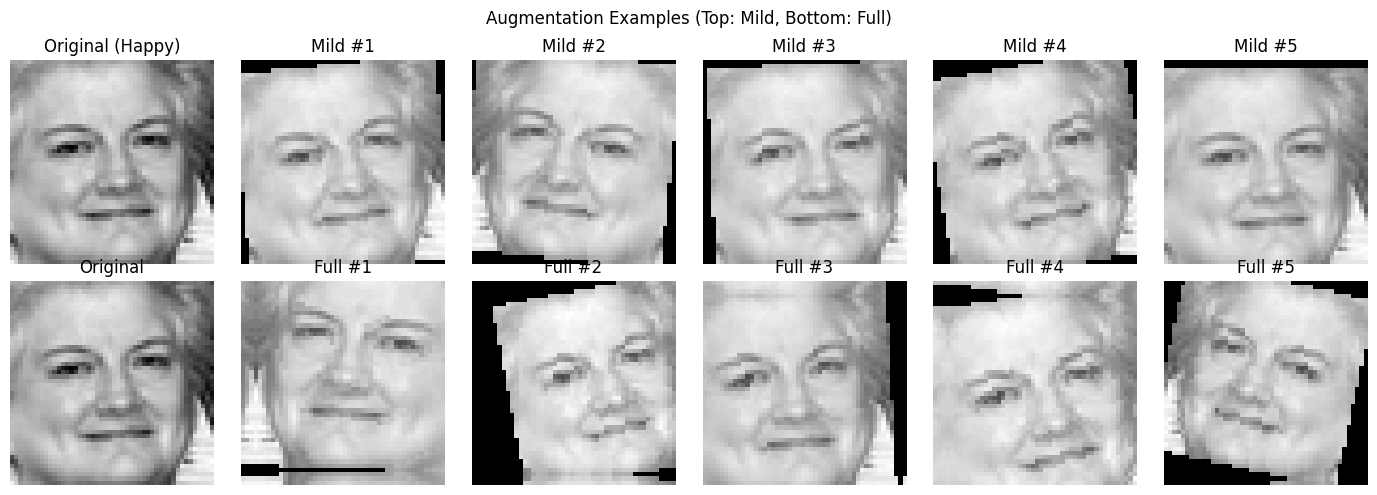

In [5]:
# Augmentation visualization
import matplotlib.pyplot as plt

sample_idx = 100
sample_img = X_train[sample_idx]
EMOTION_LABELS = {0:'Angry', 1:'Disgust', 2:'Fear', 3:'Happy', 4:'Sad', 5:'Surprise', 6:'Neutral'}

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes[0,0].imshow(sample_img, cmap='gray')
axes[0,0].set_title(f'Original ({EMOTION_LABELS[y_train[sample_idx]]})')
axes[0,0].axis('off')

# Mild aug examples
for i in range(5):
    aug = mild_aug_transform(sample_img).squeeze().numpy()
    axes[0, i+1].imshow(aug, cmap='gray')
    axes[0, i+1].set_title(f'Mild #{i+1}')
    axes[0, i+1].axis('off')

axes[1,0].imshow(sample_img, cmap='gray')
axes[1,0].set_title('Original')
axes[1,0].axis('off')

# Full aug examples
for i in range(5):
    aug = full_aug_transform(sample_img).squeeze().numpy()
    axes[1, i+1].imshow(aug, cmap='gray')
    axes[1, i+1].set_title(f'Full #{i+1}')
    axes[1, i+1].axis('off')

plt.suptitle('Augmentation Examples (Top: Mild, Bottom: Full)')
plt.tight_layout(); plt.show()

## VGG-mini Architecture

In [6]:
class VGGMini(nn.Module):
    """VGG-style mini network for 48x48 grayscale input."""
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                      # (32, 24, 24)
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                      # (64, 12, 12)
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                      # (128, 6, 6)
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                      # (256, 3, 3)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


set_seed(42)
model = VGGMini(dropout=0.5).to(device)
print(f"Trainable parameters: {count_parameters(model):,}")

Trainable parameters: 1,175,399


## Sanity Checks

In [7]:
criterion = nn.CrossEntropyLoss()
_ = sanity_check_forward(model, train_loader_a, criterion, device)

=== Forward Pass Sanity Check ===
  Batch input shape:  (64, 1, 48, 48)
  Batch output shape: (64, 7)
  Initial loss:       1.9420
  Expected (random):  1.9459  = log(7)
  Diff:               0.0040
  Trainable params:   1,175,399


In [8]:
set_seed(42)
sanity_model = VGGMini(dropout=0.0).to(device)
sanity_opt = optim.Adam(sanity_model.parameters(), lr=1e-3)
_ = sanity_check_overfit_batch(sanity_model, train_loader_a, sanity_opt, criterion, device, num_steps=150)

=== Overfit Single Batch Sanity Check (150 steps) ===
  Step    0 | loss 1.9631 | acc 0.1406
  Step   15 | loss 0.0161 | acc 1.0000
  Step   30 | loss 0.0055 | acc 1.0000
  Step   45 | loss 0.0032 | acc 1.0000
  Step   60 | loss 0.0023 | acc 1.0000
  Step   75 | loss 0.0018 | acc 1.0000
  Step   90 | loss 0.0015 | acc 1.0000
  Step  105 | loss 0.0013 | acc 1.0000
  Step  120 | loss 0.0011 | acc 1.0000
  Step  135 | loss 0.0009 | acc 1.0000
  Step  149 | loss 0.0008 | acc 1.0000
  Final batch accuracy: 1.0000
  Model can overfit a single batch - capacity OK


## Run A — VGG, NO augmentation (control)

ვნახოთ რას იძლევა მხოლოდ deeper architecture, augmentation-ის გარეშე.

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/30 | train_loss 1.4423 acc 0.4422 | val_loss 1.2927 acc 0.5007 | grad 2.684 | lr 1.00e-03
Epoch   2/30 | train_loss 1.1603 acc 0.5598 | val_loss 1.1932 acc 0.5472 | grad 2.167 | lr 9.97e-04
Epoch   3/30 | train_loss 1.0515 acc 0.6009 | val_loss 1.1229 acc 0.5737 | grad 2.081 | lr 9.89e-04
Epoch   4/30 | train_loss 0.9637 acc 0.6368 | val_loss 1.0908 acc 0.5946 | grad 2.071 | lr 9.76e-04
Epoch   5/30 | train_loss 0.8798 acc 0.6695 | val_loss 1.0422 acc 0.6110 | grad 2.132 | lr 9.57e-04
Epoch   6/30 | train_loss 0.7728 acc 0.7103 | val_loss 1.0694 acc 0.6085 | grad 2.223 | lr 9.33e-04
Epoch   7/30 | train_loss 0.6639 acc 0.7544 | val_loss 1.1527 acc 0.5977 | grad 2.357 | lr 9.05e-04
Epoch   8/30 | train_loss 0.5474 acc 0.7996 | val_loss 1.1514 acc 0.6250 | grad 2.508 | lr 8.72e-04
Epoch   9/30 | train_loss 0.4199 acc 0.8479 | val_loss 1.4000 acc 0.6091 | grad 2.601 | lr 8.35e-04
Epoch  10/30 | train_loss 0.3116 acc 0.8910 | val_loss 1.4370 acc 0.6147 | grad 2.611 | lr 7.94e-04


best_val_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
grad_norm,█▇▆▆▆▇▇████▇▇▆▆▅▅▄▃▃▃▂▂▂▁▁▁▁▁▁
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train_acc,▁▂▃▃▄▄▅▅▆▇▇▇▇█████████████████
train_loss,█▇▆▆▅▅▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▆▇▇▆█▇▇▇▇█▇▇▇▇▇█▇██████████
val_loss,▂▂▁▁▁▁▂▂▃▃▅▄▅▆▆▇▇▇▇▇██████████
best_val_acc,0.63444
epoch,30
grad_norm,0.17288


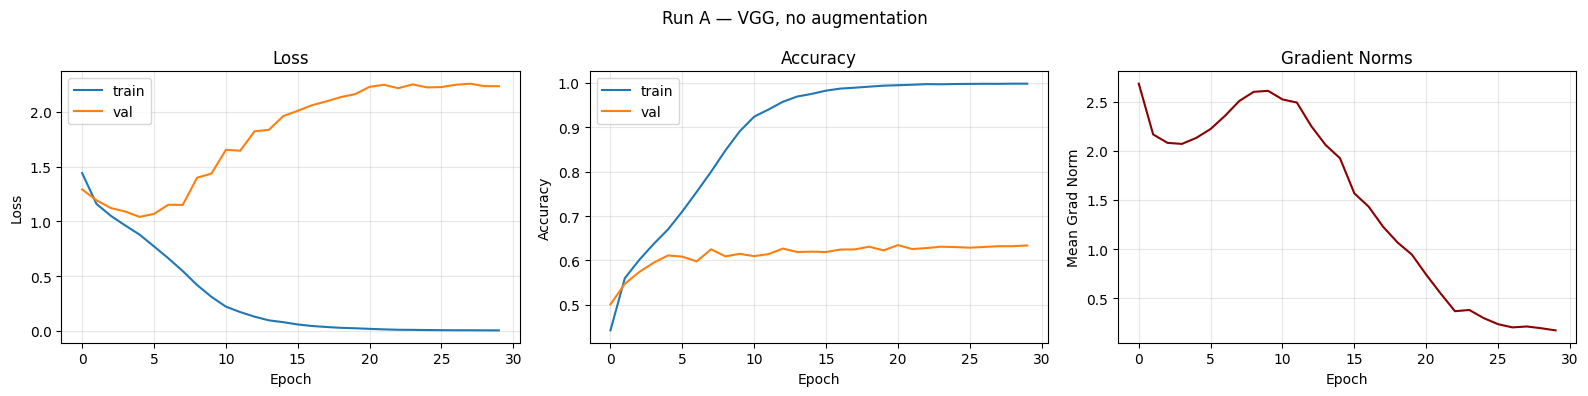

Best val acc: 0.6344
Train-Val gap: 0.3646


In [9]:
# Run A — VGG, no augmentation
set_seed(42)
model_a = VGGMini(dropout=0.5).to(device)
optimizer_a = optim.Adam(model_a.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_a = optim.lr_scheduler.CosineAnnealingLR(optimizer_a, T_max=30)

config_a = {
    'architecture': 'VGGMini',
    'num_params': count_parameters(model_a),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'dropout': 0.5,
    'batch_norm': True,
    'lr_scheduler': 'CosineAnnealingLR',
    'augmentation': 'none',
    'batch_size': BATCH_SIZE,
    'num_epochs': 30,
}

history_a, best_acc_a = train_model(
    model_a, train_loader_a, val_loader, optimizer_a, criterion, device,
    num_epochs=30, scheduler=scheduler_a,
    run_name='05_vgg_no_aug',
    project=PROJECT, config=config_a,
    save_path=f'{PROJECT_DIR}/models/05_vgg_no_aug.pt'
)
wandb.finish()
plot_training_curves(history_a, title="Run A — VGG, no augmentation")
print(f"Best val acc: {best_acc_a:.4f}")
print(f"Train-Val gap: {history_a['train_acc'][-1] - history_a['val_acc'][-1]:.4f}")

## Run B — VGG + Mild Augmentation

ვამატებთ flip + small rotation/translation augmentation-ს. ველოდებით:
- train_acc ცოტა დაიკლებს (augmentation hard-ს ხდის training-ს)
- val_acc იზრდება
- gap მცირდება

In [14]:
# Run B — VGG + mild augmentation
set_seed(42)
model_b = VGGMini(dropout=0.5).to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_b = optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=40)

config_b = {
    'architecture': 'VGGMini',
    'num_params': count_parameters(model_b),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'dropout': 0.5,
    'lr_scheduler': 'CosineAnnealingLR',
    'augmentation': 'mild (flip + rot10 + trans5%)',
    'batch_size': BATCH_SIZE,
    'num_epochs': 40,
}

history_b, best_acc_b = train_model(
    model_b, train_loader_b, val_loader, optimizer_b, criterion, device,
    num_epochs=40, scheduler=scheduler_b,
    run_name='05_vgg_mild_aug',
    project=PROJECT, config=config_b,
    save_path=f'{PROJECT_DIR}/models/05_vgg_mild_aug.pt'
)
wandb.finish()
plot_training_curves(history_b, title="Run B — VGG + Mild Augmentation")
print(f"Best val acc: {best_acc_b:.4f}")
print(f"Train-Val gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:.4f}")

Epoch   1/40 | train_loss 1.5142 acc 0.4107 | val_loss 1.3358 acc 0.4884 | grad 2.573 | lr 1.00e-03
Epoch   2/40 | train_loss 1.2497 acc 0.5216 | val_loss 1.2260 acc 0.5233 | grad 2.114 | lr 9.98e-04
Epoch   3/40 | train_loss 1.1656 acc 0.5590 | val_loss 1.2069 acc 0.5548 | grad 1.994 | lr 9.94e-04
Epoch   4/40 | train_loss 1.1195 acc 0.5753 | val_loss 1.1614 acc 0.5589 | grad 1.906 | lr 9.86e-04
Epoch   5/40 | train_loss 1.0830 acc 0.5919 | val_loss 1.0837 acc 0.5887 | grad 1.822 | lr 9.76e-04
Epoch   6/40 | train_loss 1.0585 acc 0.6044 | val_loss 1.0536 acc 0.6043 | grad 1.804 | lr 9.62e-04
Epoch   7/40 | train_loss 1.0314 acc 0.6117 | val_loss 1.0121 acc 0.6119 | grad 1.716 | lr 9.46e-04
Epoch   8/40 | train_loss 1.0055 acc 0.6213 | val_loss 1.0227 acc 0.6191 | grad 1.688 | lr 9.26e-04
Epoch   9/40 | train_loss 0.9903 acc 0.6262 | val_loss 1.0717 acc 0.6057 | grad 1.707 | lr 9.05e-04
Epoch  10/40 | train_loss 0.9696 acc 0.6377 | val_loss 1.0397 acc 0.6197 | grad 1.710 | lr 8.80e-04


KeyboardInterrupt: 

## Run C — VGG + Full Augmentation

heavy augmentation + longer training. ჯერჯერობით საუკეთესო configuration უნდა იყოს.

Epoch   1/50 | train_loss 1.6453 acc 0.3483 | val_loss 1.3574 acc 0.4731 | grad 2.395 | lr 1.00e-03
Epoch   2/50 | train_loss 1.3371 acc 0.4897 | val_loss 1.2155 acc 0.5330 | grad 2.089 | lr 9.99e-04
Epoch   3/50 | train_loss 1.2421 acc 0.5250 | val_loss 1.2685 acc 0.5280 | grad 1.971 | lr 9.96e-04
Epoch   4/50 | train_loss 1.1926 acc 0.5470 | val_loss 1.1167 acc 0.5731 | grad 1.883 | lr 9.91e-04
Epoch   5/50 | train_loss 1.1551 acc 0.5644 | val_loss 1.0870 acc 0.5929 | grad 1.797 | lr 9.84e-04
Epoch   6/50 | train_loss 1.1284 acc 0.5734 | val_loss 1.1744 acc 0.5648 | grad 1.762 | lr 9.76e-04
Epoch   7/50 | train_loss 1.1018 acc 0.5853 | val_loss 1.1218 acc 0.5829 | grad 1.718 | lr 9.65e-04
Epoch   8/50 | train_loss 1.0869 acc 0.5896 | val_loss 1.0596 acc 0.6091 | grad 1.671 | lr 9.52e-04
Epoch   9/50 | train_loss 1.0662 acc 0.5990 | val_loss 1.0752 acc 0.5991 | grad 1.686 | lr 9.38e-04
Epoch  10/50 | train_loss 1.0558 acc 0.6018 | val_loss 1.0058 acc 0.6272 | grad 1.643 | lr 9.22e-04


best_val_acc,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
grad_norm,▆▄▄▃▂▂▁▂▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▅▅▆▆▆▇▇▇▇██████
lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▅▅▅▅▆▅▆▆▆▆▆▆▆▇▇▆▇▇▇▇▇█▇█████████████
val_loss,█▆▇▄▄▄▃▄▂▃▂▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.68905
epoch,50
grad_norm,2.62414


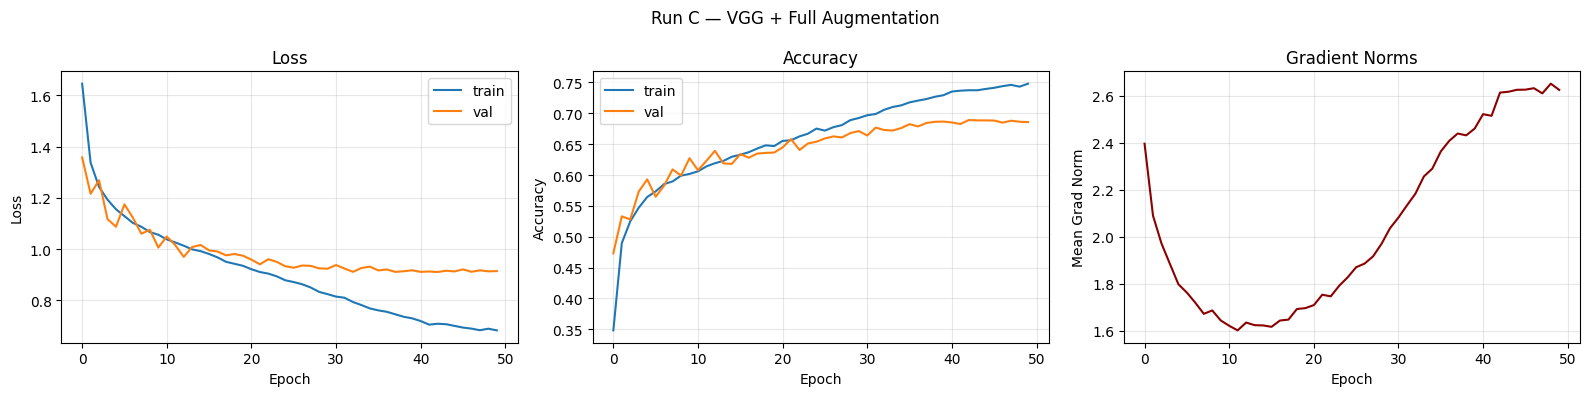

Best val acc: 0.6890
Train-Val gap: 0.0623


In [11]:
# Run C — VGG + full augmentation, longer training
set_seed(42)
model_c = VGGMini(dropout=0.5).to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.CosineAnnealingLR(optimizer_c, T_max=50)

config_c = {
    'architecture': 'VGGMini',
    'num_params': count_parameters(model_c),
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'dropout': 0.5,
    'lr_scheduler': 'CosineAnnealingLR',
    'augmentation': 'full (flip + affine + crop)',
    'batch_size': BATCH_SIZE,
    'num_epochs': 50,
}

history_c, best_acc_c = train_model(
    model_c, train_loader_c, val_loader, optimizer_c, criterion, device,
    num_epochs=50, scheduler=scheduler_c,
    run_name='05_vgg_full_aug',
    project=PROJECT, config=config_c,
    save_path=f'{PROJECT_DIR}/models/05_vgg_full_aug.pt'
)
wandb.finish()
plot_training_curves(history_c, title="Run C — VGG + Full Augmentation")
print(f"Best val acc: {best_acc_c:.4f}")
print(f"Train-Val gap: {history_c['train_acc'][-1] - history_c['val_acc'][-1]:.4f}")

## Run-ების შედარება

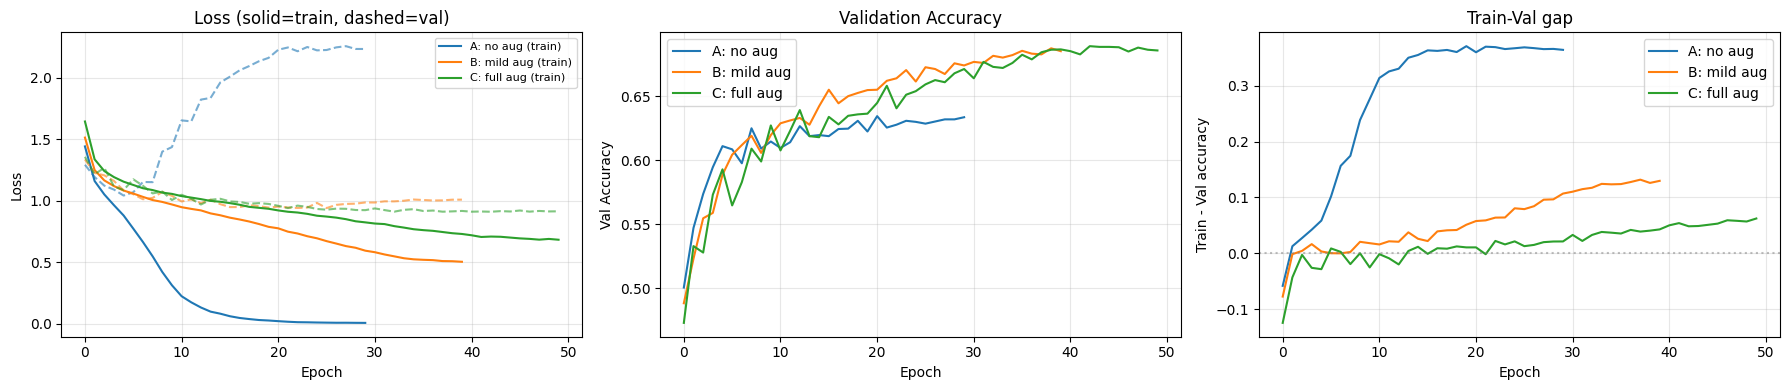


Final val accuracy comparison:
  Run A (no aug):    0.6344  [gap: +0.3646]
  Run B (mild aug):  0.6874  [gap: +0.1298]
  Run C (full aug):  0.6890  [gap: +0.0623]


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss curves
axes[0].plot(history_a['train_loss'], label='A: no aug (train)', linestyle='-')
axes[0].plot(history_a['val_loss'], linestyle='--', alpha=0.6, color='C0')
axes[0].plot(history_b['train_loss'], label='B: mild aug (train)', linestyle='-')
axes[0].plot(history_b['val_loss'], linestyle='--', alpha=0.6, color='C1')
axes[0].plot(history_c['train_loss'], label='C: full aug (train)', linestyle='-')
axes[0].plot(history_c['val_loss'], linestyle='--', alpha=0.6, color='C2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (solid=train, dashed=val)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Val accuracy
axes[1].plot(history_a['val_acc'], label='A: no aug')
axes[1].plot(history_b['val_acc'], label='B: mild aug')
axes[1].plot(history_c['val_acc'], label='C: full aug')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Train-Val gap
for h, label in [(history_a, 'A: no aug'), (history_b, 'B: mild aug'), (history_c, 'C: full aug')]:
    gaps = [t - v for t, v in zip(h['train_acc'], h['val_acc'])]
    axes[2].plot(gaps, label=label)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train - Val accuracy')
axes[2].set_title('Train-Val gap')
axes[2].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nFinal val accuracy comparison:")
print(f"  Run A (no aug):    {best_acc_a:.4f}  [gap: {history_a['train_acc'][-1] - history_a['val_acc'][-1]:+.4f}]")
print(f"  Run B (mild aug):  {best_acc_b:.4f}  [gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:+.4f}]")
print(f"  Run C (full aug):  {best_acc_c:.4f}  [gap: {history_c['train_acc'][-1] - history_c['val_acc'][-1]:+.4f}]")

## საუკეთესო Run-ის Test Evaluation

საუკეთესო Run: C (val_acc=0.6890)

Test loss: 0.8477
Test accuracy: 0.7047


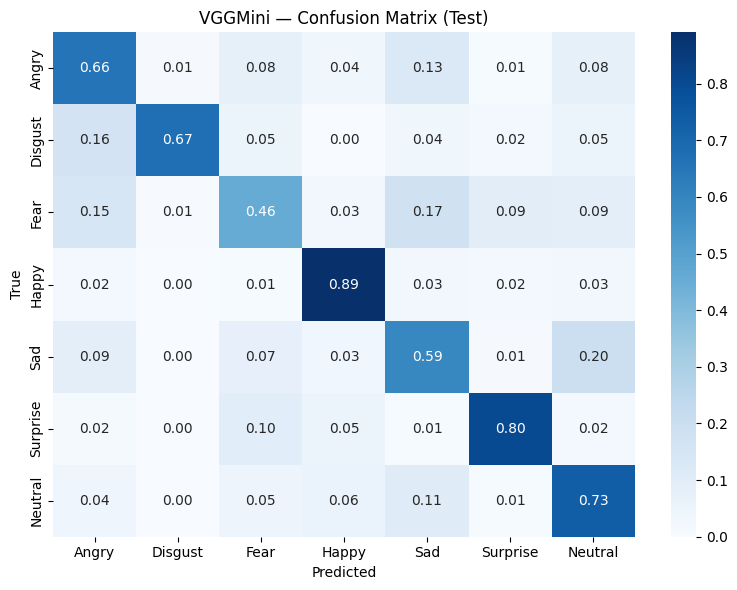

              precision    recall  f1-score   support

       Angry     0.6277    0.6558    0.6414       491
     Disgust     0.7551    0.6727    0.7115        55
        Fear     0.5946    0.4583    0.5176       528
       Happy     0.8778    0.8908    0.8842       879
         Sad     0.5835    0.5943    0.5888       594
    Surprise     0.7891    0.8005    0.7947       416
     Neutral     0.6548    0.7332    0.6918       626

    accuracy                         0.7047      3589
   macro avg     0.6975    0.6865    0.6900      3589
weighted avg     0.7021    0.7047    0.7016      3589



In [13]:
best_runs = {
    'A': (best_acc_a, f'{PROJECT_DIR}/models/05_vgg_no_aug.pt'),
    'B': (best_acc_b, f'{PROJECT_DIR}/models/05_vgg_mild_aug.pt'),
    'C': (best_acc_c, f'{PROJECT_DIR}/models/05_vgg_full_aug.pt'),
}
best_label = max(best_runs, key=lambda k: best_runs[k][0])
best_acc, best_path = best_runs[best_label]
print(f"საუკეთესო Run: {best_label} (val_acc={best_acc:.4f})")

best_model = VGGMini(dropout=0.5).to(device)
best_model.load_state_dict(torch.load(best_path))

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

preds, labels = get_predictions(best_model, test_loader, device)
_ = plot_confusion_matrix(preds, labels, title="VGGMini — Confusion Matrix (Test)")
print_classification_report(preds, labels)

## ანალიზი

**შედეგები:**
- Run A (no aug): val 63.44%, gap **36.5%** — deeper net მარტო ისევ overfit-ი
- Run B (mild aug): val 68.74%, gap **13.0%** — დიდი ნახტომი
- Run C (full aug): val 68.90%, **test 70.47%**, gap **6.2%** — overfit თითქმის გადაჭრილია

**მთავარი:** augmentation მუშაობს ბრო. gap 40% → 6%, val_acc 60% → 70% (+10pp).

**რა ხდება:**
- A-ში train 99.8%, val 63% — model memorize-ს, ისევ იგივე ისტორია
- B-ში train 81%, val 69% — augmentation train-ს ჰარდს ხდის, val იზრდება
- C-ში train 75%, val 69% — train და val თითქმის თანაბარია, generalization OK

**per-class progress (MediumCNN → VGG+full aug):**
- Happy: 0.80 → **0.88**
- Disgust: 0.58 → **0.71** (აღარაა ცუდი!)
- Macro F1: 0.59 → **0.69** (+10pp)
- Test acc: 60.69% → **70.47%** (+10pp)

შემდეგი: **06_resnet_transfer.ipynb** — pretrained ResNet18, target 75%+